In [29]:
from pathlib import Path
from collections import Counter, defaultdict
import csv
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import plotly.express as px
from plotly.offline import get_plotlyjs


# 1 Motivation
The dataset we used was shooting data from NYC as well as precinct geojson data. We chose this dataset because NYC shootings are at an all time low, as well as being very low per capita compared to other US states, so we thought it would be interesting to take a deep dive into the data, and explore historical trends, geographical and temporal patterns, demographics and lethality.

The experience we want the reader of our story to have is to get an idea of shootings in New York, how, why and when they happen, along with what has been done to minimize shootings in New York compared to other places in the USA. We want to offer the reader some cited possible explanations for why things might be the way they are without presenting it as a definitive reason and at the end of the story we want the user to be able to take a deep dive himself into the NYC shooting data with an interactive visualization that is easy to digest while still being insightful.

#### Links
Links to the NYC shooting dataset can be found here:
https://data.cityofnewyork.us/browse?q=&sortBy=relevance&utf8=%E2%9C%93&pageSize=20&Data-Collection_Data-Collection=NYPD+Shootings&page=1

Link to the precinct geojson can be found here:
https://data.cityofnewyork.us/City-Government/Police-Precincts/y76i-bdw7/about_data


# 2 Basic stats
### Data preprocessing
We took 3 key steps when preprocessing the data

The NYC shooting dataset consists of 3 datasets, shootings, victims and perpatrators, these datasets were combined into one single datasets by joining them on the column INCIDENT_KEY. This was instructed by the dataset website.

Missing values, clear errors and unknown values were standardized to 'UNKOWN' to preserve data integrity without making unsupported assumptions.

Lastly, we noticed that the dataset had it's latitude and longitude values reversed, so we corrected that for correct spatial analysis

### Key stats and points
The cleaned and combined dataset contains 24,127 incidents and spans January 2006 to March 2026.

Geographically, shootings are concentrated in Brooklyn (9,726 incidents) and the Bronx (6,979), followed by Queens (3,587), Manhattan (3,161), and Staten Island (674). The location fields also show that violence is overwhelmingly concentrated outdoors, with most incidents recorded as occurring on the street.

The exploratory plots reveal several clear temporal patterns. A yearly trend line shows a long decline from the mid-2000s into the late 2010s, reaching a low around 2018–2019, followed by a sharp rise in 2020–2021, and then a renewed decline through 2024–2025. A time-of-day plot shows shootings clustering in the late evening and around midnight, with relatively low activity in the morning hours. A day-of-week bar chart shows the highest counts on weekends, especially Sunday and Saturday. Finally, a monthly seasonality plot indicates that shootings increase in warmer months, peaking in July and August and reaching their lowest levels in February. Together, these plots suggest that shooting incidents are not only spatially concentrated, but also strongly patterned by season, weekday, and hour.

In [30]:
"""
NYPD Shooting Data — Cleaning, Preprocessing & Combination
===========================================================
Course: Social Data Analysis and Visualization (DTU)
Project: "The Blueprint Exists" — Act 3 (NYC Deep Dive)

Input files (from NYC Open Data, downloaded 2026-05-02):
  - Shootings__2006-Present__20260502.csv      (24,127 incidents)
  - Shooting_Victims__2006-Present__20260502.csv (28,912 victims)
  - Shooting_Offenders__2006-Present__20260502.csv (18,901 offenders)

Output files:
  - nypd_shootings_combined.csv  (incident-level, all three tables joined)
  - nypd_victims_clean.csv       (victim-level detail)
  - nypd_offenders_clean.csv     (offender-level detail)
"""


# ============================================================
# Configuration — adjust these paths as needed
# ============================================================

RAW_DIR = Path("./data/raw")
OUT_DIR = Path("./data/clean")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SHOOTINGS_FILE = RAW_DIR / "Shootings_(2006-Present)_20260502.csv"
VICTIMS_FILE   = RAW_DIR / "Shooting_Victims_(2006-Present)_20260502.csv"
OFFENDERS_FILE = RAW_DIR / "Shooting_Offenders_(2006-Present)_20260502.csv"

VALID_AGE_GROUPS = ["<18", "18-24", "25-44", "45-64", "65+", "UNKNOWN"]


# ============================================================
# 1. Load raw data
# ============================================================

shootings = pd.read_csv(SHOOTINGS_FILE)
victims   = pd.read_csv(VICTIMS_FILE)
offenders = pd.read_csv(OFFENDERS_FILE)

print("=== Raw data loaded ===")
print(f"  Shootings:  {shootings.shape[0]:,} rows × {shootings.shape[1]} cols")
print(f"  Victims:    {victims.shape[0]:,} rows × {victims.shape[1]} cols")
print(f"  Offenders:  {offenders.shape[0]:,} rows × {offenders.shape[1]} cols")


# ============================================================
# 2. Clean Shootings table
# ============================================================

# 2a. Fix lat/lon swap
#     The source CSV has the columns mislabeled:
#       "Latitude" column contains longitude values (~-73.7 to -74.2)
#       "Longitude" column contains latitude values (~40.5 to 40.9)
shootings = shootings.rename(columns={
    "Latitude":  "Longitude_raw",
    "Longitude": "Latitude_raw",
})
shootings = shootings.rename(columns={
    "Longitude_raw": "Longitude",
    "Latitude_raw":  "Latitude",
})

# Sanity check: NYC lat should be ~40.5–40.9, lon ~-74.3 to -73.7
assert shootings["Latitude"].dropna().between(40.4, 41.0).all(), \
    "Latitude values out of expected NYC range after swap"
assert shootings["Longitude"].dropna().between(-74.3, -73.6).all(), \
    "Longitude values out of expected NYC range after swap"

# 2b. Parse datetime and extract temporal features
shootings["datetime"] = pd.to_datetime(
    shootings["OCCUR_DATE"] + " " + shootings["OCCUR_TIME"],
    format="%m/%d/%Y %H:%M:%S",
)
shootings["year"]        = shootings["datetime"].dt.year
shootings["month"]       = shootings["datetime"].dt.month
shootings["day_of_week"] = shootings["datetime"].dt.day_name()
shootings["hour"]        = shootings["datetime"].dt.hour

# 2c. Fill missing jurisdiction codes
#     2 rows have NaN — fill with -1 to indicate "unknown"
shootings["JURISDICTION_CODE"] = (
    shootings["JURISDICTION_CODE"].fillna(-1).astype(int)
)

print(f"\n=== Shootings cleaned ===")
print(f"  Lat/lon swap corrected")
print(f"  Datetime parsed, temporal features extracted")
print(f"  Null counts:\n{shootings.isnull().sum().to_string()}")


# ============================================================
# 3. Clean Victims table
# ============================================================

# 3a. Fix dirty age values
#     Found 1 invalid entry: "1022" — likely a data entry error
dirty_victim_ages = victims[~victims["VICTIM_AGE_GROUP"].isin(VALID_AGE_GROUPS)]
if len(dirty_victim_ages) > 0:
    print(f"\n=== Dirty victim age values (→ UNKNOWN) ===")
    print(f"  {dirty_victim_ages['VICTIM_AGE_GROUP'].value_counts().to_dict()}")
    victims.loc[
        ~victims["VICTIM_AGE_GROUP"].isin(VALID_AGE_GROUPS),
        "VICTIM_AGE_GROUP",
    ] = "UNKNOWN"

# 3b. Fill NaN in string demographic columns
for col in ["VICTIM_AGE_GROUP", "VICTIM_SEX", "VICTIM_RACE"]:
    victims[col] = victims[col].fillna("UNKNOWN")

# 3c. Create boolean murder flag
victims["is_murder"] = victims["STAT_MURDER_FLG"] == "Y"

print(f"\n=== Victims cleaned: {victims.shape[0]:,} rows ===")


# ============================================================
# 4. Clean Offenders table
# ============================================================

# 4a. Fix dirty age values
#     Found 6 invalid entries: 1020, 1028, 2021, 940, 224, 1822
dirty_perp_ages = offenders[~offenders["PERP_AGE_GROUP"].isin(VALID_AGE_GROUPS)]
if len(dirty_perp_ages) > 0:
    print(f"\n=== Dirty perp age values (→ UNKNOWN) ===")
    print(f"  {dirty_perp_ages['PERP_AGE_GROUP'].value_counts().to_dict()}")
    offenders.loc[
        ~offenders["PERP_AGE_GROUP"].isin(VALID_AGE_GROUPS),
        "PERP_AGE_GROUP",
    ] = "UNKNOWN"

# 4b. Fill NaN in string demographic columns
for col in ["PERP_AGE_GROUP", "PERP_SEX", "PERP_RACE"]:
    offenders[col] = offenders[col].fillna("UNKNOWN")

print(f"\n=== Offenders cleaned: {offenders.shape[0]:,} rows ===")


# ============================================================
# 5. Combine into incident-level master table
# ============================================================

# 5a. Aggregate victim info per incident
vic_agg = (
    victims.groupby("INCIDENT_KEY")
    .agg(
        num_victims=("VICTIM_ID", "count"),
        num_murdered=("is_murder", "sum"),
        victim_age_groups=("VICTIM_AGE_GROUP", lambda x: "|".join(x.astype(str))),
        victim_sexes=("VICTIM_SEX", lambda x: "|".join(x.astype(str))),
        victim_races=("VICTIM_RACE", lambda x: "|".join(x.astype(str))),
    )
    .reset_index()
)
vic_agg["num_murdered"] = vic_agg["num_murdered"].astype(int)
vic_agg["has_fatality"] = vic_agg["num_murdered"] > 0

# 5b. Aggregate offender info per incident
off_agg = (
    offenders.groupby("INCIDENT_KEY")
    .agg(
        num_offenders=("PERP_ID", "count"),
        perp_age_groups=("PERP_AGE_GROUP", lambda x: "|".join(x.astype(str))),
        perp_sexes=("PERP_SEX", lambda x: "|".join(x.astype(str))),
        perp_races=("PERP_RACE", lambda x: "|".join(x.astype(str))),
    )
    .reset_index()
)

# 5c. Left join: shootings ← victims ← offenders
#     Left join ensures every incident is kept even if victim/offender
#     records are missing (2 victim keys and 1 offender key are orphans
#     in the raw data — they get dropped by the left join on shootings)
combined = shootings.merge(vic_agg, on="INCIDENT_KEY", how="left")
combined = combined.merge(off_agg, on="INCIDENT_KEY", how="left")

# 5d. Mark offender data availability
combined["has_offender_data"] = combined["num_offenders"].notna()
combined["num_offenders"] = combined["num_offenders"].fillna(0).astype(int)


# ============================================================
# 6. Summary statistics
# ============================================================

print("\n" + "=" * 60)
print("COMBINED DATASET SUMMARY")
print("=" * 60)
print(f"Shape: {combined.shape[0]:,} rows × {combined.shape[1]} cols")
print(f"Year range: {combined['year'].min()} – {combined['year'].max()}")
print(f"Latitude range:  {combined['Latitude'].min():.4f} – {combined['Latitude'].max():.4f}")
print(f"Longitude range: {combined['Longitude'].min():.4f} – {combined['Longitude'].max():.4f}")
print(f"Total victims across all incidents: {combined['num_victims'].sum():,}")
print(f"Total fatalities: {combined['num_murdered'].sum():,}")
print(f"Incidents with fatalities: {combined['has_fatality'].sum():,} "
      f"({100 * combined['has_fatality'].mean():.1f}%)")
print(f"Incidents with offender data: {combined['has_offender_data'].sum():,} "
      f"({100 * combined['has_offender_data'].mean():.1f}%)")
print(f"Incidents with NO offender data: "
      f"{(~combined['has_offender_data']).sum():,} "
      f"({100 * (~combined['has_offender_data']).mean():.1f}%)")

print(f"\nPartial years:")
for y in [2025, 2026]:
    n = (combined["year"] == y).sum()
    max_month = combined.loc[combined["year"] == y, "month"].max()
    print(f"  {y}: {n} incidents (data through month {max_month})")

print(f"\nIncidents per year (2006–2024):")
yearly = combined[combined["year"] <= 2024].groupby("year").size()
print(yearly.to_string())


# ============================================================
# 7. Save cleaned files
# ============================================================

combined.to_csv(OUT_DIR / "nypd_shootings_combined.csv", index=False)
victims.to_csv(OUT_DIR / "nypd_victims_clean.csv", index=False)
offenders.to_csv(OUT_DIR / "nypd_offenders_clean.csv", index=False)

print(f"\n=== Files saved to {OUT_DIR}/ ===")
print(f"  nypd_shootings_combined.csv  ({combined.shape[0]:,} rows)")
print(f"  nypd_victims_clean.csv       ({victims.shape[0]:,} rows)")
print(f"  nypd_offenders_clean.csv     ({offenders.shape[0]:,} rows)")


=== Raw data loaded ===
  Shootings:  24,127 rows × 13 cols
  Victims:    28,912 rows × 6 cols
  Offenders:  18,901 rows × 5 cols

=== Shootings cleaned ===
  Lat/lon swap corrected
  Datetime parsed, temporal features extracted
  Null counts:
INCIDENT_KEY              0
OCCUR_DATE                0
OCCUR_TIME                0
BORO                      0
LOC_OF_OCCUR_DESC         0
PRECINCT                  0
JURISDICTION_CODE         0
LOC_CLASSFCTN_DESC       33
LOCATION_DESC         14434
X_COORD_CD                1
Y_COORD_CD                1
Longitude                 1
Latitude                  1
datetime                  0
year                      0
month                     0
day_of_week               0
hour                      0

=== Dirty victim age values (→ UNKNOWN) ===
  {'1022': 1}

=== Victims cleaned: 28,912 rows ===

=== Dirty perp age values (→ UNKNOWN) ===
  {'1020': 1, '1028': 1, '2021': 1, '940': 1, '224': 1, '1822': 1}

=== Offenders cleaned: 18,901 rows ===

COMB

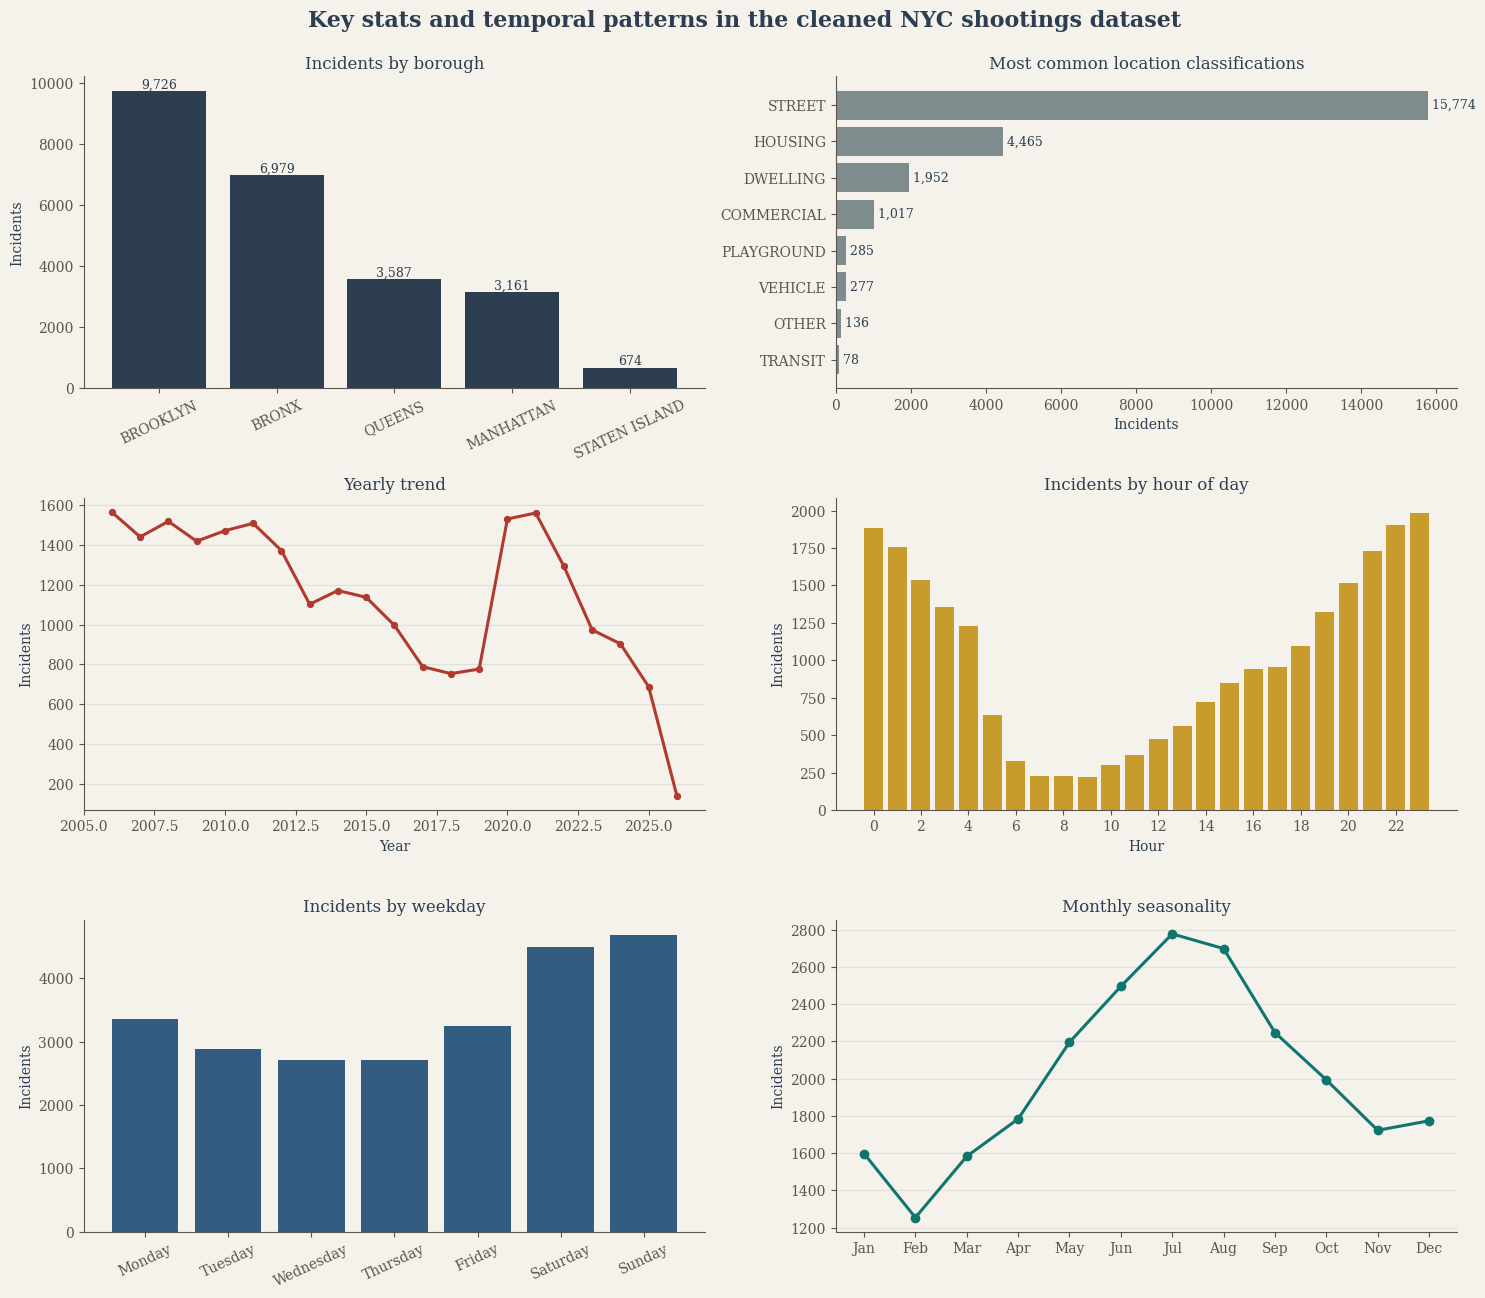

,metric,value
0,Total incidents,"24,127"
1,Date range,January 2006 to March 2026
2,Largest borough count,"Brooklyn (9,726)"
3,Weekend peak day,"Sunday (4,693)"
4,Peak month,"Jul (2,778)"
5,Peak hour,"23:00 (1,985)"


In [31]:
# Plots for key stats and points

data_path = "./data/nypd_shootings_combined.csv"
key_stats = pd.read_csv(data_path, parse_dates=["datetime"])
key_stats = key_stats.dropna(subset=["year", "BORO"]).copy()
key_stats["year"] = key_stats["year"].astype(int)
key_stats["month"] = key_stats["month"].fillna(0).astype(int)
key_stats["hour"] = key_stats["hour"].fillna(0).astype(int)

boro_order = ["BROOKLYN", "BRONX", "QUEENS", "MANHATTAN", "STATEN ISLAND"]
boro_counts = key_stats["BORO"].value_counts().reindex(boro_order)
location_counts = key_stats["LOC_CLASSFCTN_DESC"].fillna("Unknown").value_counts().head(8)
yearly_counts = key_stats.groupby("year").size()
hour_counts = key_stats.groupby("hour").size().reindex(range(24), fill_value=0)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_counts = key_stats["day_of_week"].value_counts().reindex(weekday_order)
month_counts = key_stats.groupby("month").size().reindex(range(1, 13), fill_value=0)
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(3, 2, figsize=(15, 13))
fig.suptitle("Key stats and temporal patterns in the cleaned NYC shootings dataset", fontsize=16, fontweight="bold", y=0.995)

axes[0, 0].bar(boro_counts.index, boro_counts.values, color="#2c3e50")
axes[0, 0].set_title("Incidents by borough")
axes[0, 0].set_ylabel("Incidents")
axes[0, 0].tick_params(axis="x", rotation=25)
for i, value in enumerate(boro_counts.values):
    axes[0, 0].text(i, value, f"{value:,}", ha="center", va="bottom", fontsize=9)

axes[0, 1].barh(location_counts.index[::-1], location_counts.values[::-1], color="#7f8c8d")
axes[0, 1].set_title("Most common location classifications")
axes[0, 1].set_xlabel("Incidents")
for i, value in enumerate(location_counts.values[::-1]):
    axes[0, 1].text(value, i, f" {value:,}", va="center", fontsize=9)

axes[1, 0].plot(yearly_counts.index, yearly_counts.values, color="#b03a2e", linewidth=2.2)
axes[1, 0].scatter(yearly_counts.index, yearly_counts.values, color="#b03a2e", s=18)
axes[1, 0].set_title("Yearly trend")
axes[1, 0].set_ylabel("Incidents")
axes[1, 0].set_xlabel("Year")
axes[1, 0].grid(True, axis="y", alpha=0.25)

axes[1, 1].bar(hour_counts.index, hour_counts.values, color="#c79c2c")
axes[1, 1].set_title("Incidents by hour of day")
axes[1, 1].set_xlabel("Hour")
axes[1, 1].set_ylabel("Incidents")
axes[1, 1].set_xticks(range(0, 24, 2))

axes[2, 0].bar(weekday_counts.index, weekday_counts.values, color="#335c81")
axes[2, 0].set_title("Incidents by weekday")
axes[2, 0].set_ylabel("Incidents")
axes[2, 0].tick_params(axis="x", rotation=25)

axes[2, 1].plot(month_labels, month_counts.values, color="#0f766e", linewidth=2.2, marker="o")
axes[2, 1].set_title("Monthly seasonality")
axes[2, 1].set_ylabel("Incidents")
axes[2, 1].grid(True, axis="y", alpha=0.25)

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "metric": [
        "Total incidents",
        "Date range",
        "Largest borough count",
        "Weekend peak day",
        "Peak month",
        "Peak hour",
    ],
    "value": [
        f"{len(key_stats):,}",
        f"{key_stats['datetime'].min():%B %Y} to {key_stats['datetime'].max():%B %Y}",
        f"{boro_counts.idxmax().title()} ({boro_counts.max():,})",
        f"{weekday_counts.idxmax()} ({weekday_counts.max():,})",
        f"{month_labels[int(month_counts.idxmax()) - 1]} ({month_counts.max():,})",
        f"{int(hour_counts.idxmax()):02d}:00 ({hour_counts.max():,})",
    ],
})
summary


In [32]:
# Load the cleaned project datasets and apply the typing used by the visualizations.

shootings = pd.read_csv("./data/nypd_shootings_combined.csv", parse_dates=["datetime"])
victims = pd.read_csv("./data/nypd_victims_clean.csv")
offenders = pd.read_csv("./data/nypd_offenders_clean.csv")

shootings = shootings.dropna(subset=["year", "BORO", "PRECINCT"]).copy()
shootings["year"] = shootings["year"].astype(int)
shootings["month"] = shootings["month"].fillna(0).astype(int)
shootings["hour"] = shootings["hour"].fillna(0).astype(int)
shootings["PRECINCT"] = shootings["PRECINCT"].astype(int).astype(str)
shootings["num_victims"] = shootings["num_victims"].fillna(0).astype(int)
shootings["num_murdered"] = shootings["num_murdered"].fillna(0).astype(int)
shootings["has_fatality"] = shootings["num_murdered"] > 0

for col in [
    "BORO", "day_of_week", "victim_age_groups", "victim_sexes", "victim_races",
    "perp_age_groups", "perp_sexes", "perp_races", "LOC_CLASSFCTN_DESC",
]:
    if col in shootings.columns:
        shootings[col] = shootings[col].fillna("Unknown").astype(str)

print("shootings", shootings.shape)
print("victims", victims.shape)
print("offenders", offenders.shape)
shootings.head()


shootings (24127, 29)
victims (28912, 7)
offenders (18901, 5)


,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,...,num_murdered,victim_age_groups,victim_sexes,victim_races,has_fatality,num_offenders,perp_age_groups,perp_sexes,perp_races,has_offender_data
0,212200405,04/20/2020,19:36:00,BROOKLYN,OUTSIDE,79,2,HOUSING,MULTI DWELL - PUBLIC HOUS,1000301.0,...,1,25-44,MALE,BLACK,True,0,Unknown,Unknown,Unknown,False
1,139554478,11/07/2014,03:20:00,BRONX,INSIDE,42,0,DWELLING,PVT HOUSE,1012185.0,...,0,45-64,MALE,BLACK,False,1,25-44,MALE,BLACK,True
2,167619814,08/01/2017,00:35:00,BRONX,OUTSIDE,47,2,HOUSING,MULTI DWELL - PUBLIC HOUS,1030360.0,...,0,18-24,MALE,WHITE HISPANIC,False,1,25-44,MALE,WHITE HISPANIC,True
3,212516311,04/29/2020,15:30:00,BRONX,OUTSIDE,46,0,STREET,NaN,1009085.0,...,0,<18,MALE,BLACK,False,0,Unknown,Unknown,Unknown,False
4,270150948,06/20/2023,23:41:00,QUEENS,OUTSIDE,108,0,STREET,NaN,1004925.0,...,0,25-44,MALE,WHITE HISPANIC,False,2,25-44|25-44,MALE|MALE,BLACK|WHITE HISPANIC,True


# 3 Data analysis
From our data analysis we saw that the dataset includeds a lot of useful columns, and with the combined dataset we could see important descriptions of most shootings from 2006 until present such as the geography, demography, which precint it belongs to and at what time it took place.

In [33]:
# Basic aggregates used in the data story and visualization design.

TREND_START_YEAR = 2006
TREND_END_YEAR = min(2025, int(shootings["year"].max()))
trend = shootings.query("@TREND_START_YEAR <= year <= @TREND_END_YEAR").copy()

yearly = (trend.groupby("year", as_index=False)
          .agg(incidents=("INCIDENT_KEY", "count"),
               victims=("num_victims", "sum"),
               fatalities=("num_murdered", "sum")))
yearly["fatality_rate"] = yearly["fatalities"] / yearly["victims"].replace(0, np.nan)

borough_year = (trend.pivot_table(index="year", columns="BORO", values="INCIDENT_KEY", aggfunc="count", fill_value=0)
                .reset_index())
borough_year["NYC"] = borough_year.drop(columns="year").sum(axis=1)

monthly = trend.groupby("month", as_index=False).size().rename(columns={"size": "incidents"})
day_hour = trend.groupby(["day_of_week", "hour"], as_index=False).size().rename(columns={"size": "incidents"})

victim_age = victims.groupby("VICTIM_AGE_GROUP", as_index=False).size().rename(columns={"size": "victims"})
victim_sex = victims.groupby("VICTIM_SEX", as_index=False).size().rename(columns={"size": "victims"})
offender_age = offenders.groupby("PERP_AGE_GROUP", as_index=False).size().rename(columns={"size": "offenders"})

print("Yearly trend")
display(yearly.tail())
print("Borough trend")
display(borough_year.tail())
print("Victim age distribution")
display(victim_age)


Yearly trend


,year,incidents,victims,fatalities,fatality_rate
15,2021,1562,1876,325,0.173241
16,2022,1294,1566,254,0.162197
17,2023,974,1150,207,0.180000
18,2024,904,1103,180,0.163191
19,2025,688,856,146,0.170561


Borough trend


BORO,year,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND,NYC
15,2021,508,519,262,237,36,1562
16,2022,408,449,211,198,28,1294
17,2023,316,338,162,131,27,974
18,2024,338,287,145,119,15,904
19,2025,252,245,90,90,11,688


Victim age distribution


,VICTIM_AGE_GROUP,victims
0,18-24,10428
1,25-44,13254
2,45-64,1973
3,65+,209
4,<18,2989
5,UNKNOWN,59


# 4 Genre
Here we talk about what Genre, visual narrative and narrative structure follows, as described in Narrative Visualization: Telling Stories with Data by Segel and Heer http://vis.stanford.edu/files/2010-Narrative-InfoVis.pdf

Our data story is an author-driven magazine piece, with the martini glass structure. The user is guided through the story of New York Shootings since 2006 and at the end is met with an interactive visualization where they can freely explore every part of the story.

## Visual narrative
#### Visual structuring
Our data story an establishing shot with the title of the story along with some stats about the dataset and has a consistent visual platform

#### Highlighting
Our story contains 4 highlighting features, close-up and zooming, when we are talking about the geographical elements of the data we zoom in on a single borough and show a close-up of the concentration there. We also include feature distinction, for example in chapter 4 when we show the distribution of shootings per month, the summer months are colored red to show their significance. Lastly we use some motion when displaying bar charts in Chapter 4 and 5.

#### Transition guidance
The transition guidance in our story is continous editing where the user cuts between 5 chapters with different visualizations, which are all a part of the same story.

## Narrative structure
#### Ordering
We have linear ordering, because we want to guide the user first through the story, so that it is more easily digestable, and so he is more prepared to explore freely at the end of the story.

#### Interactivity
Our story contains limited interactivity, however some visualizations do include hover highlighting, filtering and zooming.

#### Messaging
Our story contains Captions, annotations, Introductory text and Summary text. Since the story is a linear story, we want to introduce certain topics one at a time, so we have a caption for each topic we introduce. Some static visualizations have annotations so that it is easier to see how certain events may have affected shootings. We also include introduction text to hook people into the story and a summary text to prepare the user for the free exploration.

# 5 Visualizations
As discussed our story is told in 5 chapters so the visualizations we chose can be described as such

#### Chapter 1: Overall trend
- Line graph displaying the overall count of gun crimes per year, overall and for each borough. We chose this visualization to make it clear to the reader shootings are going down as well as to show that shootings don't happen equally as often in each borough.

#### Chapter 2: Shootings geographics
- A Leaflet symbol map with one dot per shooting incident, precinct boundaries for geographic context, and scroll steps that focus first on all incidents, then Brooklyn and the Bronx, then precincts 75, 73, and 67. We replaced the earlier heatmap because the dot layer keeps individual incidents visible while the precinct overlay makes the geographic concentration easier to interpret.

#### Chapter 3: Demographic
- Bar chart showing victim age distribution.
- Bar chart showing offender age distribution.
- Pie chart showing victim gender distribution.
- Bar chart showing victim fatality rate by age.
These visualizations are right for our story because in this chapter we are talking about demographics and we want the reader to quickly and effectively see the distribution of victims and offenders, and we thought bar charts was the best option for that. The pie chart was chosen to highlight the huge difference between male and female victims.

#### Chapter 4: Time patterns
- Heatmap showing shootings per hour and day
- Bar chart showing shooting distributions per month
The bar chart was chosen for the same reason as the bar charts in chapter 3, to quickly show the distribution to help give the reader an idea of the shootings distribution per month.
The heatmap we chose to show the temporal pattern and we wanted to include day of week and time of day in the visualization, and we decided that the heatmap was the best way to do that.


#### Chapter 5: Shooting lethality
- Stacked bar chart showing shooting count per year with lethal shootings stacked on top
- Bar chart showing the share of shootings that were fatal in each borough.
We wanted to have the stacked bar chart to display to the reader quickly the ratio between fatal and non fatal shootings per year, and the percentage bar chart we chose to display to the user that regardless of shooting counts, the lethality is not the same in each borough.


#### Final visualization
The story ends with an interactive visualization that contains a map of NYC with each borough being marked with a different color and that color being brighter/darker depending on shooting incidents for a selected time period, the reader can also toggle on and off dots on the map that each represent a single incident. The visualization then has controls for each of the earlier discussed matters in the deep dive.

We chose this visualization because our story does not claim something with irrefutable evidence, we explore the data and suggest some possible explanation but at the end we feel it's important to let the user freely explore the data with controls for all topics mentioned so that he can explore the data also without our help.


In [34]:
# Makes the chapter 2 map
chapter2_data_path = Path("data/nypd_shootings_combined.csv")
chapter2_geojson_path = Path("data/nyc_police_precincts.geojson")
chapter2_output = Path("output/chapter2_leaflet_symbol_map.html")
chapter2_output.parent.mkdir(parents=True, exist_ok=True)

chapter2_df = pd.read_csv(chapter2_data_path)
chapter2_df = chapter2_df.dropna(subset=["year", "BORO", "PRECINCT", "Latitude", "Longitude"]).copy()
chapter2_df["year"] = chapter2_df["year"].astype(int)
chapter2_df["PRECINCT"] = chapter2_df["PRECINCT"].astype(int)
chapter2_df["num_murdered"] = chapter2_df["num_murdered"].fillna(0).astype(int)
chapter2_df = chapter2_df.query("2006 <= year <= 2026")

chapter2_records = chapter2_df[[
    "INCIDENT_KEY", "year", "BORO", "PRECINCT", "Latitude", "Longitude", "num_murdered"
]].rename(columns={
    "INCIDENT_KEY": "key",
    "BORO": "boro",
    "PRECINCT": "precinct",
    "Latitude": "lat",
    "Longitude": "lon",
    "num_murdered": "numMurdered",
}).to_dict(orient="records")

chapter2_geojson = json.loads(chapter2_geojson_path.read_text(encoding="utf-8"))
chapter2_precinct_boro = (
    chapter2_df.groupby(chapter2_df["PRECINCT"].astype(str))["BORO"]
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
    .to_dict()
)

chapter2_html = """<!doctype html>
<html lang=\"en\">
<head>
  <meta charset=\"utf-8\">
  <meta name=\"viewport\" content=\"width=device-width, initial-scale=1\">
  <title>Chapter 2 — NYC shooting incident map</title>
  <link rel=\"stylesheet\" href=\"https://unpkg.com/leaflet@1.9.4/dist/leaflet.css\">
  <script src=\"https://unpkg.com/leaflet@1.9.4/dist/leaflet.js\"></script>
  <style>
    body { margin: 0; font-family: Georgia, serif; background: #f5f1eb; color: #1f1d1a; }
    .wrap { padding: 18px; }
    #map { height: 720px; border: 1px solid #c9c1ae; border-radius: 6px; background: #ece6d8; }
    .controls { display: flex; gap: 8px; flex-wrap: wrap; margin-bottom: 10px; }
    button { border: 1px solid #c9c1ae; background: #fffaf2; color: #1f1d1a; border-radius: 4px; padding: 8px 10px; cursor: pointer; }
    button.active { background: #2c3e50; color: #fff; border-color: #2c3e50; }
    .title { font-weight: 700; font-size: 20px; margin-bottom: 4px; }
    .subtitle { color: #5a554e; margin-bottom: 12px; }
  </style>
</head>
<body>
  <div class=\"wrap\">
    <div class=\"title\" id=\"title\">All shootings, 2006–2026</div>
    <div class=\"subtitle\" id=\"subtitle\">Every NYPD-recorded shooting incident, with precinct boundaries for context</div>
    <div class=\"controls\">
      <button data-step=\"map-1\" class=\"active\">All incidents</button>
      <button data-step=\"map-2\">Brooklyn + Bronx</button>
      <button data-step=\"map-3\">Precincts 75, 73, 67</button>
    </div>
    <div id=\"map\"></div>
  </div>
<script>
const incidents = __INCIDENTS__;
const precinctGeoJson = __GEOJSON__;
const precinctBoro = __PRECINCT_BORO__;
const MAP_BORO_COLORS = {BRONX: '#b03a2e', BROOKLYN: '#2c3e50', MANHATTAN: '#c79c2c', QUEENS: '#7f8c8d', 'STATEN ISLAND': '#6a4c93'};

const map = L.map('map', { preferCanvas: true, zoomSnap: 0.5 }).setView([40.72, -73.93], 11);
map.createPane('precinctPane'); map.getPane('precinctPane').style.zIndex = 360;
map.createPane('mapLabels'); map.getPane('mapLabels').style.zIndex = 560;
map.createPane('shootingDots'); map.getPane('shootingDots').style.zIndex = 620;
L.tileLayer('https://{s}.basemaps.cartocdn.com/light_nolabels/{z}/{x}/{y}{r}.png', { attribution: '© OpenStreetMap, © CARTO', maxZoom: 19, subdomains: 'abcd' }).addTo(map);
L.tileLayer('https://{s}.basemaps.cartocdn.com/light_only_labels/{z}/{x}/{y}{r}.png', { maxZoom: 19, subdomains: 'abcd', pane: 'mapLabels' }).addTo(map);
const renderer = L.canvas({ padding: 0.35, pane: 'shootingDots' });
let dotLayer = null;

function precinctNumber(feature) { return String(feature?.properties?.precinct ?? ''); }
function isActive(step, precinct, boro) {
  if (step === 'map-2') return boro === 'BROOKLYN' || boro === 'BRONX';
  if (step === 'map-3') return ['75', '73', '67'].includes(precinct);
  return true;
}
function styleFor(step) {
  return feature => {
    const p = precinctNumber(feature);
    const boro = precinctBoro[p] || 'UNKNOWN';
    const active = isActive(step, p, boro);
    const focus = step === 'map-3' && active;
    return {
      color: focus ? '#7d1e16' : 'rgba(31, 29, 26, 0.25)',
      weight: focus ? 1.8 : active ? 1 : 0.55,
      opacity: focus ? 0.95 : active ? 0.55 : 0.18,
      fillColor: focus ? '#b03a2e' : MAP_BORO_COLORS[boro] || '#8f948f',
      fillOpacity: focus ? 0.3 : active ? 0.14 : 0.035,
    };
  };
}
const precinctLayer = L.geoJSON(precinctGeoJson, { pane: 'precinctPane', interactive: false, style: styleFor('map-1') }).addTo(map);

function drawDots(points, step) {
  if (dotLayer) map.removeLayer(dotLayer);
  const radius = step === 'map-3' ? 3.4 : step === 'map-2' ? 2.8 : 2.2;
  const fillOpacity = step === 'map-3' ? 0.72 : step === 'map-2' ? 0.6 : 0.44;
  const group = L.layerGroup();
  points.forEach(d => {
    L.circleMarker([d.lat, d.lon], {
      renderer, radius, interactive: false, stroke: true,
      color: 'rgba(255, 253, 248, 0.75)', weight: d.numMurdered > 0 ? 0.9 : 0.45,
      fill: true, fillColor: d.numMurdered > 0 ? '#b03a2e' : '#202124', fillOpacity,
    }).addTo(group);
  });
  dotLayer = group.addTo(map);
}
function render(step) {
  let pts = incidents;
  let title = 'All shootings, 2006–2026';
  let subtitle = 'Every NYPD-recorded shooting incident, with precinct boundaries for context';
  let center = [40.72, -73.93];
  let zoom = 11;
  if (step === 'map-2') {
    pts = pts.filter(d => d.boro === 'BROOKLYN' || d.boro === 'BRONX');
    title = 'Brooklyn + the Bronx';
    subtitle = 'The dot layer narrows to the two boroughs that account for 69% of recorded shootings';
  } else if (step === 'map-3') {
    pts = pts.filter(d => [75, 73, 67].includes(d.precinct));
    title = 'Precincts 75, 73, 67';
    subtitle = 'East New York, Brownsville, and East Flatbush remain visible while the rest of the city recedes';
    center = [40.665, -73.91]; zoom = 12.5;
  }
  document.getElementById('title').textContent = title;
  document.getElementById('subtitle').textContent = subtitle;
  precinctLayer.setStyle(styleFor(step));
  drawDots(pts, step);
  map.flyTo(center, zoom, { duration: 0.8 });
}
document.querySelectorAll('button[data-step]').forEach(btn => {
  btn.addEventListener('click', () => {
    document.querySelectorAll('button[data-step]').forEach(b => b.classList.toggle('active', b === btn));
    render(btn.dataset.step);
  });
});
render('map-1');
</script>
</body>
</html>
"""
chapter2_html = (chapter2_html
    .replace("__INCIDENTS__", json.dumps(chapter2_records, separators=(",", ":")))
    .replace("__GEOJSON__", json.dumps(chapter2_geojson, separators=(",", ":")))
    .replace("__PRECINCT_BORO__", json.dumps(chapter2_precinct_boro, separators=(",", ":")))
)
chapter2_output.write_text(chapter2_html, encoding="utf-8")
print(f"Wrote {chapter2_output.resolve()}")
print(f"Included {len(chapter2_records):,} incident dots")


Wrote /Users/binni/DTU/Social data & analysis/social-data-analysis-and-visualization-02806-assignments/final_project/output/chapter2_leaflet_symbol_map.html
Included 24,126 incident dots


In [35]:


ROOT = Path.cwd().resolve()
FIG = ROOT / "generated" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

BG = "#f5f1eb"
FG = "#2c3e50"
ACCENT = "#b03a2e"
MUTED = "#5a554e"

plt.rcParams.update(
    {
        "figure.facecolor": BG,
        "axes.facecolor": BG,
        "axes.edgecolor": MUTED,
        "axes.labelcolor": FG,
        "text.color": FG,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "font.size": 10,
    }
)

dash = json.loads((ROOT / "generated" / "dashboard_data.json").read_text(encoding="utf-8"))
agg = dash["agg"]
meta = dash["meta"]
y0, y1 = meta["trend_start_year"], meta["trend_end_year"]

# --- Borough lines + NYC total ---
boro_rows = agg["boroYearRows"]
years = [r["year"] for r in boro_rows]
plt.figure(figsize=(10, 5))
plt.plot(years, [r["NYC"] for r in boro_rows], color=FG, linewidth=2.8, label="NYC total")
colors = {"BRONX": "#8b5a2b", "BROOKLYN": ACCENT, "MANHATTAN": FG, "QUEENS": "#5d6d7e", "STATEN ISLAND": "#95a5a6"}
for b, c in colors.items():
    plt.plot(years, [r[b] for r in boro_rows], color=c, linewidth=1.5, alpha=0.9, label=b.title())
plt.xlabel("Year")
plt.ylabel("Shooting incidents")
plt.title("NYPD shooting incidents — NYC and boroughs")
plt.legend(loc="upper right", fontsize=8, framealpha=0.9)
plt.xticks(range(min(years), max(years) + 1))
plt.tight_layout()
plt.savefig(FIG / "borough_trends.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Yearly incidents ---
yr = agg["yearly"]
plt.figure(figsize=(10, 4))
plt.plot([r["year"] for r in yr], [r["n"] for r in yr], color=FG, marker="o", markersize=3)
plt.xlabel("Year")
plt.ylabel("Incidents")
plt.title(f"Citywide shooting incidents ({y0}–{y1})")
plt.xticks([r["year"] for r in yr])
plt.tight_layout()
plt.savefig(FIG / "citywide_trend.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Fatal vs non-fatal (incident-level, same rule as page: has_fatality) ---
fatal_by_y = {}
nf_by_y = {}
for row in dash["incidents"]:
    y = row["year"]
    if y < y0 or y > y1:
        continue
    if row["fatal"]:
        fatal_by_y[y] = fatal_by_y.get(y, 0) + 1
    else:
        nf_by_y[y] = nf_by_y.get(y, 0) + 1

ys = list(range(y0, y1 + 1))
fatal = [fatal_by_y.get(y, 0) for y in ys]
nf = [nf_by_y.get(y, 0) for y in ys]
plt.figure(figsize=(10, 4))
plt.bar(ys, nf, color=FG, alpha=0.85, label="Non-fatal incident")
plt.bar(ys, fatal, bottom=nf, color=ACCENT, alpha=0.9, label="≥1 fatality")
plt.xlabel("Year")
plt.ylabel("Incidents")
plt.title("Fatal vs non-fatal incidents by year")
plt.legend()
plt.xticks(ys)
plt.tight_layout()
plt.savefig(FIG / "fatal_stack.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved PNGs to", FIG)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/binni/DTU/Social data & analysis/social-data-analysis-and-visualization-02806-assignments/final_project/generated/dashboard_data.json'

In [ ]:
# Generates the final interactive visualization
data_path = "./data/nypd_shootings_combined.csv"
geojson_path = Path("./data/nyc_police_precincts.geojson")
output_dir = Path("./output")
html_path = output_dir / "nyc_shootings_precinct_map_explorer.html"

output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path, parse_dates=["datetime"])
df = df.dropna(subset=["year", "BORO", "PRECINCT", "Latitude", "Longitude"]).copy()
df["year"] = df["year"].astype(int)
df["month"] = df["month"].fillna(0).astype(int)
df["hour"] = df["hour"].fillna(0).astype(int)
df["PRECINCT"] = df["PRECINCT"].astype(int).astype(str)
df["num_victims"] = df["num_victims"].fillna(0).astype(int)
df["num_murdered"] = df["num_murdered"].fillna(0).astype(int)
df["has_fatality"] = df["num_murdered"] > 0

for col in [
    "BORO",
    "day_of_week",
    "victim_age_groups",
    "victim_sexes",
    "victim_races",
    "perp_age_groups",
    "perp_sexes",
    "perp_races",
    "LOC_CLASSFCTN_DESC",
]:
    df[col] = df[col].fillna("Unknown").astype(str)

geojson = json.loads(geojson_path.read_text(encoding="utf-8"))
for feature in geojson["features"]:
    feature["id"] = str(feature["properties"]["precinct"])

precinct_boro = (
    df.groupby("PRECINCT")["BORO"]
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
    .to_dict()
)
precincts = sorted([str(feature["properties"]["precinct"]) for feature in geojson["features"]], key=lambda x: int(x))

records = df[[
    "INCIDENT_KEY", "year", "month", "day_of_week", "hour", "BORO", "PRECINCT",
    "Latitude", "Longitude", "num_victims", "num_murdered", "has_fatality",
    "victim_age_groups", "victim_sexes", "victim_races", "perp_age_groups",
    "perp_sexes", "perp_races", "LOC_CLASSFCTN_DESC",
]].rename(columns={
    "INCIDENT_KEY": "id",
    "BORO": "boro",
    "PRECINCT": "precinct",
    "Latitude": "lat",
    "Longitude": "lon",
    "LOC_CLASSFCTN_DESC": "location_class",
}).to_dict(orient="records")

meta = {
    "minYear": int(df["year"].min()),
    "maxYear": int(df["year"].max()),
    "boroughs": sorted(df["BORO"].unique().tolist()),
    "precincts": precincts,
    "precinctBoro": {p: precinct_boro.get(p, "UNKNOWN") for p in precincts},
    "totals": {
        "incidents": int(len(df)),
        "victims": int(df["num_victims"].sum()),
        "fatalities": int(df["num_murdered"].sum()),
    },
}

plotly_js = get_plotlyjs()
records_json = json.dumps(records, separators=(",", ":"))
geojson_json = json.dumps(geojson, separators=(",", ":"))
meta_json = json.dumps(meta, separators=(",", ":"))

html_template = """<!doctype html>
<html lang=\"en\">
<head>
  <meta charset=\"utf-8\">
  <meta name=\"viewport\" content=\"width=device-width, initial-scale=1\">
  <title>NYC Shooting Precinct Map Explorer</title>
  <script>__PLOTLY_JS__</script>
  <style>
    :root { --bg: #f7f7f4; --panel: #ffffff; --ink: #202124; --muted: #5d646b; --line: #d9ddd6; --active: #202124; }
    * { box-sizing: border-box; }
    body { margin: 0; font-family: Inter, ui-sans-serif, system-ui, -apple-system, BlinkMacSystemFont, \"Segoe UI\", sans-serif; color: var(--ink); background: var(--bg); }
    header { padding: 20px 28px 12px; border-bottom: 1px solid var(--line); background: #fbfbf8; }
    h1 { margin: 0 0 7px; font-size: 27px; line-height: 1.15; font-weight: 760; letter-spacing: 0; }
    .subtitle { margin: 0; max-width: 1100px; color: var(--muted); font-size: 14px; line-height: 1.45; }
    .viz-layout { display: grid; grid-template-columns: minmax(0, 1fr) 390px; gap: 16px; padding: 14px 28px 24px; align-items: start; }
    .controls { min-height: 760px; display: grid; grid-template-columns: 1fr; gap: 14px; align-content: start; padding: 16px; background: #eff1ec; border: 1px solid var(--line); border-radius: 8px; overflow: auto; }
    .control-group { display: grid; gap: 10px; padding: 12px; background: rgba(255, 255, 255, 0.72); border: 1px solid var(--line); border-radius: 8px; }
    .control-title { color: var(--ink); font-size: 12px; font-weight: 780; text-transform: uppercase; letter-spacing: 0; }
    label { display: grid; gap: 5px; color: #3f464b; font-size: 11px; font-weight: 720; text-transform: uppercase; letter-spacing: 0; }
    select, input { min-width: 0; width: 100%; border: 1px solid #bfc7c0; border-radius: 6px; padding: 8px 9px; background: white; color: var(--ink); font-size: 13px; }
    .button-row { display: flex; gap: 6px; flex-wrap: wrap; }
    button { border: 1px solid #bfc7c0; border-radius: 6px; padding: 8px 10px; background: white; color: var(--ink); font-size: 13px; cursor: pointer; }
    button.active { border-color: var(--active); background: var(--active); color: white; }
    .toggle { display: flex; align-items: center; gap: 8px; min-height: 36px; text-transform: none; font-size: 13px; font-weight: 650; }
    .toggle input { width: auto; }
    .map-wrap { min-width: 0; }
    .kpis { display: grid; grid-template-columns: repeat(4, minmax(130px, 1fr)); gap: 10px; margin-bottom: 10px; }
    .kpi { background: white; border: 1px solid var(--line); border-radius: 8px; padding: 10px 12px; }
    .kpi strong { display: block; font-size: 22px; line-height: 1.1; }
    .kpi span { display: block; margin-top: 4px; color: var(--muted); font-size: 12px; }
    #map { width: 100%; height: 760px; border: 1px solid var(--line); border-radius: 8px; overflow: hidden; background: white; }
    .note { margin: 8px 2px 0; color: var(--muted); font-size: 12px; line-height: 1.4; }
    @media (max-width: 980px) { .viz-layout { grid-template-columns: 1fr; padding: 14px; } .controls { min-height: 0; grid-template-columns: 1fr 1fr; } }
    @media (max-width: 700px) { header { padding-left: 14px; padding-right: 14px; } .controls { grid-template-columns: 1fr; } .kpis { grid-template-columns: 1fr 1fr; } #map { height: 620px; } }
  </style>
</head>
<body>
  <header>
    <h1>NYC Shooting Incidents by Police Precinct</h1>
    <p class=\"subtitle\">Precinct color identifies borough, while deeper color means a higher selected concentration of shootings. Use the sliders and buttons to decide which incidents appear; turn the dots on to inspect individual shootings.</p>
  </header>
  <main class=\"viz-layout\">
  <section class=\"map-wrap\">
    <section class=\"kpis\"><div class=\"kpi\"><strong id=\"kpiIncidents\">0</strong><span>shooting incidents</span></div><div class=\"kpi\"><strong id=\"kpiVictims\">0</strong><span>people shot</span></div><div class=\"kpi\"><strong id=\"kpiFatalities\">0</strong><span>fatalities</span></div><div class=\"kpi\"><strong id=\"kpiPeak\">0</strong><span>highest precinct concentration</span></div></section>
    <div id=\"map\"></div>
    <p class=\"note\">Source: combined NYPD shooting incidents dataset and NYC police precinct GeoJSON. One incident with missing coordinates is excluded from dot mapping.</p>
  </section>
  <section class=\"controls\" aria-label=\"Map controls\">
    <div class=\"control-group\">
    <div class=\"control-title\">Time</div>
    <label><span>Start year: <span id=\"startYearLabel\">__MIN_YEAR__</span></span><input id=\"startYear\" type=\"range\" min=\"__MIN_YEAR__\" max=\"__MAX_YEAR__\" value=\"__MIN_YEAR__\"></label>
    <label><span>End year: <span id=\"endYearLabel\">__MAX_YEAR__</span></span><input id=\"endYear\" type=\"range\" min=\"__MIN_YEAR__\" max=\"__MAX_YEAR__\" value=\"__MAX_YEAR__\"></label>
    <label>Month<select id=\"monthFilter\"><option value=\"All\">All months</option></select></label>
    <label>Weekday<select id=\"dayFilter\"><option value=\"All\">All days</option></select></label>
    <label><span>Start hour: <span id=\"hourStartLabel\">00:00</span></span><input id=\"hourStart\" type=\"range\" min=\"0\" max=\"23\" value=\"0\"></label>
    <label><span>End hour: <span id=\"hourEndLabel\">23:00</span></span><input id=\"hourEnd\" type=\"range\" min=\"0\" max=\"23\" value=\"23\"></label>
    </div>
    <div class=\"control-group\">
    <div class=\"control-title\">Map metric</div>
    <label>Metric<select id=\"metric\"><option value=\"incidents\">Incidents</option><option value=\"victims\">People shot</option><option value=\"fatalities\">Fatalities</option><option value=\"fatalRate\">Fatal incident rate</option></select></label>
    </div>
    <div class=\"control-group\">
    <div class=\"control-title\">Place and incident type</div>
    <label>Borough<select id=\"borough\"><option value=\"All\">All boroughs</option></select></label>
    <label>Fatality<span class=\"button-row\"><button type=\"button\" class=\"active\" data-fatal=\"All\">All</button><button type=\"button\" data-fatal=\"Fatal\">Fatal</button><button type=\"button\" data-fatal=\"Nonfatal\">Nonfatal</button></span></label>
    </div>
    <div class=\"control-group\">
    <div class=\"control-title\">People involved</div>
    <label>Victim age<select id=\"victimAge\"><option value=\"All\">All victim ages</option></select></label>
    <label>Perpetrator age<select id=\"perpAge\"><option value=\"All\">All perpetrator ages</option></select></label>
    <label>Demographic<select id=\"demoField\"><option value=\"none\">No demographic filter</option><option value=\"victim_races\">Victim race</option><option value=\"victim_age_groups\">Victim age</option><option value=\"victim_sexes\">Victim sex</option><option value=\"perp_races\">Perpetrator race</option><option value=\"perp_age_groups\">Perpetrator age</option><option value=\"perp_sexes\">Perpetrator sex</option></select></label>
    <label>Value<select id=\"demoValue\"><option value=\"All\">All values</option></select></label>
    </div>
    <div class=\"control-group\">
    <div class=\"control-title\">Display</div>
    <label class=\"toggle\"><input id=\"showDots\" type=\"checkbox\" checked>Show shooting locations</label>
    </div>
  </section>
  </main>
  <script>
    const records = __RECORDS__;
    const geojson = __GEOJSON__;
    const meta = __META__;
    const boroughColors = { "BROOKLYN": {low: "#cfe8e4", high: "#0f766e"}, "BRONX": {low: "#f0cbd0", high: "#b23a48"}, "QUEENS": {low: "#cdddec", high: "#335c81"}, "MANHATTAN": {low: "#eadfbd", high: "#7a5c1c"}, "STATEN ISLAND": {low: "#ded4ea", high: "#6a4c93"}, "UNKNOWN": {low: "#eeeeee", high: "#777777"} };
    const boroughOrder = ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"];
    let fatalMode = "All";
    let activeRangeInput = null;
    const boroughSelect = document.getElementById("borough");
    boroughOrder.forEach(boro => { const opt = document.createElement("option"); opt.value = boro; opt.textContent = boro; boroughSelect.appendChild(opt); });
    const monthNames = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"];
    const dayOrder = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"];
    function addOptions(selectId, values) { const select = document.getElementById(selectId); values.forEach(item => { const opt = document.createElement("option"); opt.value = item.value; opt.textContent = item.label; select.appendChild(opt); }); }
    function sortedValues(field) { const counts = new Map(); records.forEach(d => splitValues(d[field]).forEach(v => { const normalized = v.toUpperCase() === "UNKNOWN" ? "Unknown" : v; counts.set(normalized, (counts.get(normalized) || 0) + 1); })); return Array.from(counts.keys()).filter(v => v !== "Unknown").sort((a, b) => { const order = ["<18", "18-24", "25-44", "45-64", "65+"]; return (order.indexOf(a) === -1 ? 99 : order.indexOf(a)) - (order.indexOf(b) === -1 ? 99 : order.indexOf(b)) || a.localeCompare(b); }).map(v => ({value: v, label: v})); }
    addOptions("monthFilter", monthNames.map((name, idx) => ({value: String(idx + 1), label: name})));
    addOptions("dayFilter", dayOrder.map(day => ({value: day, label: day})));
    addOptions("victimAge", sortedValues("victim_age_groups"));
    addOptions("perpAge", sortedValues("perp_age_groups"));
    function fmt(x) { return Number(x).toLocaleString("en-US"); }
    function pct(x) { return `${(Number(x) || 0).toFixed(1)}%`; }
    function splitValues(value) { if (!value || value === "Unknown" || value === "nan") return ["Unknown"]; return String(value).split("|").map(v => v.trim()).filter(Boolean); }
    function syncYearLabels() { const startInput = document.getElementById("startYear"); const endInput = document.getElementById("endYear"); let start = Number(startInput.value); let end = Number(endInput.value); if (end < start) { if (activeRangeInput === "endYear") { end = start; endInput.value = end; } else { start = end; startInput.value = start; } } document.getElementById("startYearLabel").textContent = start; document.getElementById("endYearLabel").textContent = end; return {start, end}; }
    function syncHourLabels() { const startInput = document.getElementById("hourStart"); const endInput = document.getElementById("hourEnd"); let start = Number(startInput.value); let end = Number(endInput.value); if (end < start) { if (activeRangeInput === "hourEnd") { end = start; endInput.value = end; } else { start = end; startInput.value = start; } } document.getElementById("hourStartLabel").textContent = `${String(start).padStart(2, "0")}:00`; document.getElementById("hourEndLabel").textContent = `${String(end).padStart(2, "0")}:00`; return {start, end}; }
    function populateDemoValues() { const field = document.getElementById("demoField").value; const select = document.getElementById("demoValue"); select.innerHTML = '<option value="All">All values</option>'; if (field === "none") return; const counts = new Map(); records.forEach(d => splitValues(d[field]).forEach(v => counts.set(v, (counts.get(v) || 0) + 1))); Array.from(counts.entries()).filter(([v]) => v !== "Unknown").sort((a, b) => b[1] - a[1] || a[0].localeCompare(b[0])).forEach(([value]) => { const opt = document.createElement("option"); opt.value = value; opt.textContent = value; select.appendChild(opt); }); }
    function filteredRecords() { const years = syncYearLabels(); const hours = syncHourLabels(); const boro = document.getElementById("borough").value; const month = document.getElementById("monthFilter").value; const day = document.getElementById("dayFilter").value; const victimAge = document.getElementById("victimAge").value; const perpAge = document.getElementById("perpAge").value; const demoField = document.getElementById("demoField").value; const demoValue = document.getElementById("demoValue").value; return records.filter(d => { if (d.year < years.start || d.year > years.end) return false; if (d.hour < hours.start || d.hour > hours.end) return false; if (month !== "All" && Number(d.month) !== Number(month)) return false; if (day !== "All" && d.day_of_week !== day) return false; if (boro !== "All" && d.boro !== boro) return false; if (fatalMode === "Fatal" && !d.has_fatality) return false; if (fatalMode === "Nonfatal" && d.has_fatality) return false; if (victimAge !== "All" && !splitValues(d.victim_age_groups).includes(victimAge)) return false; if (perpAge !== "All" && !splitValues(d.perp_age_groups).includes(perpAge)) return false; if (demoField !== "none" && demoValue !== "All" && !splitValues(d[demoField]).includes(demoValue)) return false; return true; }); }
    function metricValue(bucket, metric) { if (metric === "victims") return bucket.victims; if (metric === "fatalities") return bucket.fatalities; if (metric === "fatalRate") return bucket.incidents ? 100 * bucket.fatalIncidents / bucket.incidents : 0; return bucket.incidents; }
    function aggregateByPrecinct(data) { const buckets = new Map(); meta.precincts.forEach(p => buckets.set(p, {incidents: 0, victims: 0, fatalities: 0, fatalIncidents: 0})); data.forEach(d => { const p = String(d.precinct); if (!buckets.has(p)) buckets.set(p, {incidents: 0, victims: 0, fatalities: 0, fatalIncidents: 0}); const b = buckets.get(p); b.incidents += 1; b.victims += Number(d.num_victims || 0); b.fatalities += Number(d.num_murdered || 0); b.fatalIncidents += d.has_fatality ? 1 : 0; }); return buckets; }
    function tracesFor(data) { const metric = document.getElementById("metric").value; const selectedBoro = document.getElementById("borough").value; const showDots = document.getElementById("showDots").checked; const buckets = aggregateByPrecinct(data); const values = meta.precincts.map(p => metricValue(buckets.get(p), metric)); const maxValue = Math.max(1, ...values); const traces = []; boroughOrder.forEach(boro => { const locations = meta.precincts.filter(p => meta.precinctBoro[p] === boro); const z = locations.map(p => metricValue(buckets.get(p), metric)); const customdata = locations.map(p => { const b = buckets.get(p); return [p, boro, b.incidents, b.victims, b.fatalities, b.incidents ? 100 * b.fatalIncidents / b.incidents : 0]; }); traces.push({ type: "choroplethmapbox", geojson, locations, z, featureidkey: "properties.precinct", zmin: 0, zmax: maxValue, colorscale: [[0, boroughColors[boro].low], [1, boroughColors[boro].high]], marker: {line: {color: "#ffffff", width: 1.15}, opacity: selectedBoro === "All" || selectedBoro === boro ? 0.82 : 0.18}, showscale: false, name: boro, customdata, hovertemplate: "Precinct %{customdata[0]}<br>%{customdata[1]}<br>Incidents: %{customdata[2]:,}<br>People shot: %{customdata[3]:,}<br>Fatalities: %{customdata[4]:,}<br>Fatal incident rate: %{customdata[5]:.1f}%<extra></extra>" }); }); traces.push({ type: "scattermapbox", lat: data.map(d => d.lat), lon: data.map(d => d.lon), mode: "markers", visible: showDots, marker: { size: data.map(d => d.has_fatality ? 8 : 5), color: data.map(d => d.has_fatality ? "#b23a48" : "#202124"), opacity: 0.68 }, text: data.map(d => `${d.boro} precinct ${d.precinct}`), customdata: data.map(d => [d.year, d.month, d.hour, d.num_victims, d.num_murdered, d.location_class]), name: "Shooting dots", hoverinfo: showDots ? "all" : "skip", hovertemplate: showDots ? "%{text}<br>Year: %{customdata[0]}<br>Month: %{customdata[1]} | Hour: %{customdata[2]}:00<br>People shot: %{customdata[3]}<br>Fatalities: %{customdata[4]}<br>%{customdata[5]}<extra></extra>" : null }); return {traces, maxValue}; }
    function updateKpis(data, maxValue) { const incidents = data.length; const victims = data.reduce((s, d) => s + Number(d.num_victims || 0), 0); const fatalities = data.reduce((s, d) => s + Number(d.num_murdered || 0), 0); const metric = document.getElementById("metric").value; document.getElementById("kpiIncidents").textContent = fmt(incidents); document.getElementById("kpiVictims").textContent = fmt(victims); document.getElementById("kpiFatalities").textContent = fmt(fatalities); document.getElementById("kpiPeak").textContent = metric === "fatalRate" ? pct(maxValue) : fmt(maxValue); }
    function render() { const data = filteredRecords(); const result = tracesFor(data); updateKpis(data, result.maxValue); const metricLabel = document.getElementById("metric").selectedOptions[0].textContent; const layout = { title: {text: `Precinct concentration by ${metricLabel.toLowerCase()}`, x: 0.02, xanchor: "left"}, margin: {l: 0, r: 0, t: 44, b: 0}, paper_bgcolor: "white", font: {family: "Inter, system-ui, sans-serif", color: "#202124"}, showlegend: true, legend: {orientation: "h", x: 0.01, y: 0.01, bgcolor: "rgba(255,255,255,0.82)"}, mapbox: {style: "white-bg", center: {lat: 40.7128, lon: -73.94}, zoom: 9.55}, uirevision: "keep-map-position" }; Plotly.react("map", result.traces, layout, {responsive: true, displaylogo: false}); }
    document.querySelectorAll("button[data-fatal]").forEach(btn => { btn.addEventListener("click", () => { fatalMode = btn.dataset.fatal; document.querySelectorAll("button[data-fatal]").forEach(b => b.classList.toggle("active", b === btn)); render(); }); });
    ["startYear", "endYear", "hourStart", "hourEnd"].forEach(id => { const el = document.getElementById(id); el.addEventListener("input", () => { activeRangeInput = id; render(); }); el.addEventListener("change", () => { activeRangeInput = id; render(); }); });
    ["monthFilter", "dayFilter", "metric", "borough", "victimAge", "perpAge", "demoValue", "showDots"].forEach(id => { document.getElementById(id).addEventListener("input", render); document.getElementById(id).addEventListener("change", render); });
    document.getElementById("demoField").addEventListener("change", () => { populateDemoValues(); render(); });
    populateDemoValues(); render();
  </script>
</body>
</html>
"""

html = (html_template
    .replace('__PLOTLY_JS__', plotly_js)
    .replace('__RECORDS__', records_json)
    .replace('__GEOJSON__', geojson_json)
    .replace('__META__', meta_json)
    .replace('__MIN_YEAR__', str(meta['minYear']))
    .replace('__MAX_YEAR__', str(meta['maxYear']))
)

html_path.write_text(html, encoding='utf-8')
print(f"Wrote {html_path.resolve()}")
print(meta['totals'])


Wrote /Users/binni/DTU/Social data & analysis/social-data-analysis-and-visualization-02806-assignments/final_project/output/nyc_shootings_precinct_map_explorer.html
{'incidents': 24126, 'victims': 28909, 'fatalities': 4809}


# 6 Discussion
#### What went well?
There were a lot of thinks that went well in our opinion, we could find some explanation for various factors that contribute to shootings in NYC, we opened up a possibility for readers to take a deep dive into shootings in NYC for themselves with an insightful interactive visualization.

#### What is still missing? What could be improved? Why?
Some things we think might be missing are comparisons between NYC and other american cities and states, so an improvement to our creation could add that comparison. Since NYC shootings are so low compared to other states that could be an interesting comparison to look at, there might be some factors such as laws that NYC has that other states don't have which contribute to this fact. Another thing that is missing that could be interesting to look at is how other crimes in NYC compared to shootings, and if some of the same factors that contribute to the decline of shootings in NYC also contribute to the decline/rise of other crimes.

# 7 Contributions
#### Adam Ajane
took lead on data preprocessing and cleaning the data, and website styling

#### Brynjar Bjarkason 
Took lead on visualization selection and writing.

#### Sævar Reynisson 
took lead on story ideation and writing.



# 8 References